In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('weatherHistory.csv', on_bad_lines='skip')


In [3]:
df

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [4]:
# 2. Վերցնում ենք 500 պատահական տող և միանգամից կոկիկացնում ինդեքսները (0-ից 499)
df_sample = df.sample(500, random_state=2026).reset_index(drop=True)

# 3. Սահմանում ենք մեր կարևոր սյունակների անունները
all_features = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)', 'Apparent Temperature (C)']

# 4. Ստիպում ենք Python-ին բոլոր սյունակները դարձնել թվային (float)
for col in all_features:
    df_sample[col] = pd.to_numeric(df_sample[col], errors='coerce')

# 5. Ջնջում ենք այն տողերը, որոնցում փոխարկումից հետո NaN է առաջացել
df_sample = df_sample.dropna(subset=all_features)

# 6 Չենք ներառում ավելորդ սյուները
df_sample = df_sample[all_features]

# Ցուցադրում ենք արդյունքը
df_sample

,Temperature (C),Humidity,Wind Speed (km/h),Visibility (km),Pressure (millibars),Apparent Temperature (C)
0,19.677778,0.47,24.8584,9.9820,1012.28,19.677778
1,3.888889,0.92,3.2200,1.4490,1020.70,3.888889
2,0.377778,0.96,13.5240,0.3220,1035.41,-3.650000
3,14.883333,1.00,14.4900,11.1251,1004.55,14.883333
4,7.116667,1.00,3.5259,6.7781,1028.54,7.116667
...,...,...,...,...,...,...
495,13.083333,0.96,6.2468,14.8120,1010.15,13.083333
496,21.850000,0.70,27.7081,6.2951,1012.55,21.850000
497,2.894444,0.95,25.4058,7.2128,1019.73,-2.216667
498,18.288889,0.93,9.9820,14.9086,1010.68,18.288889


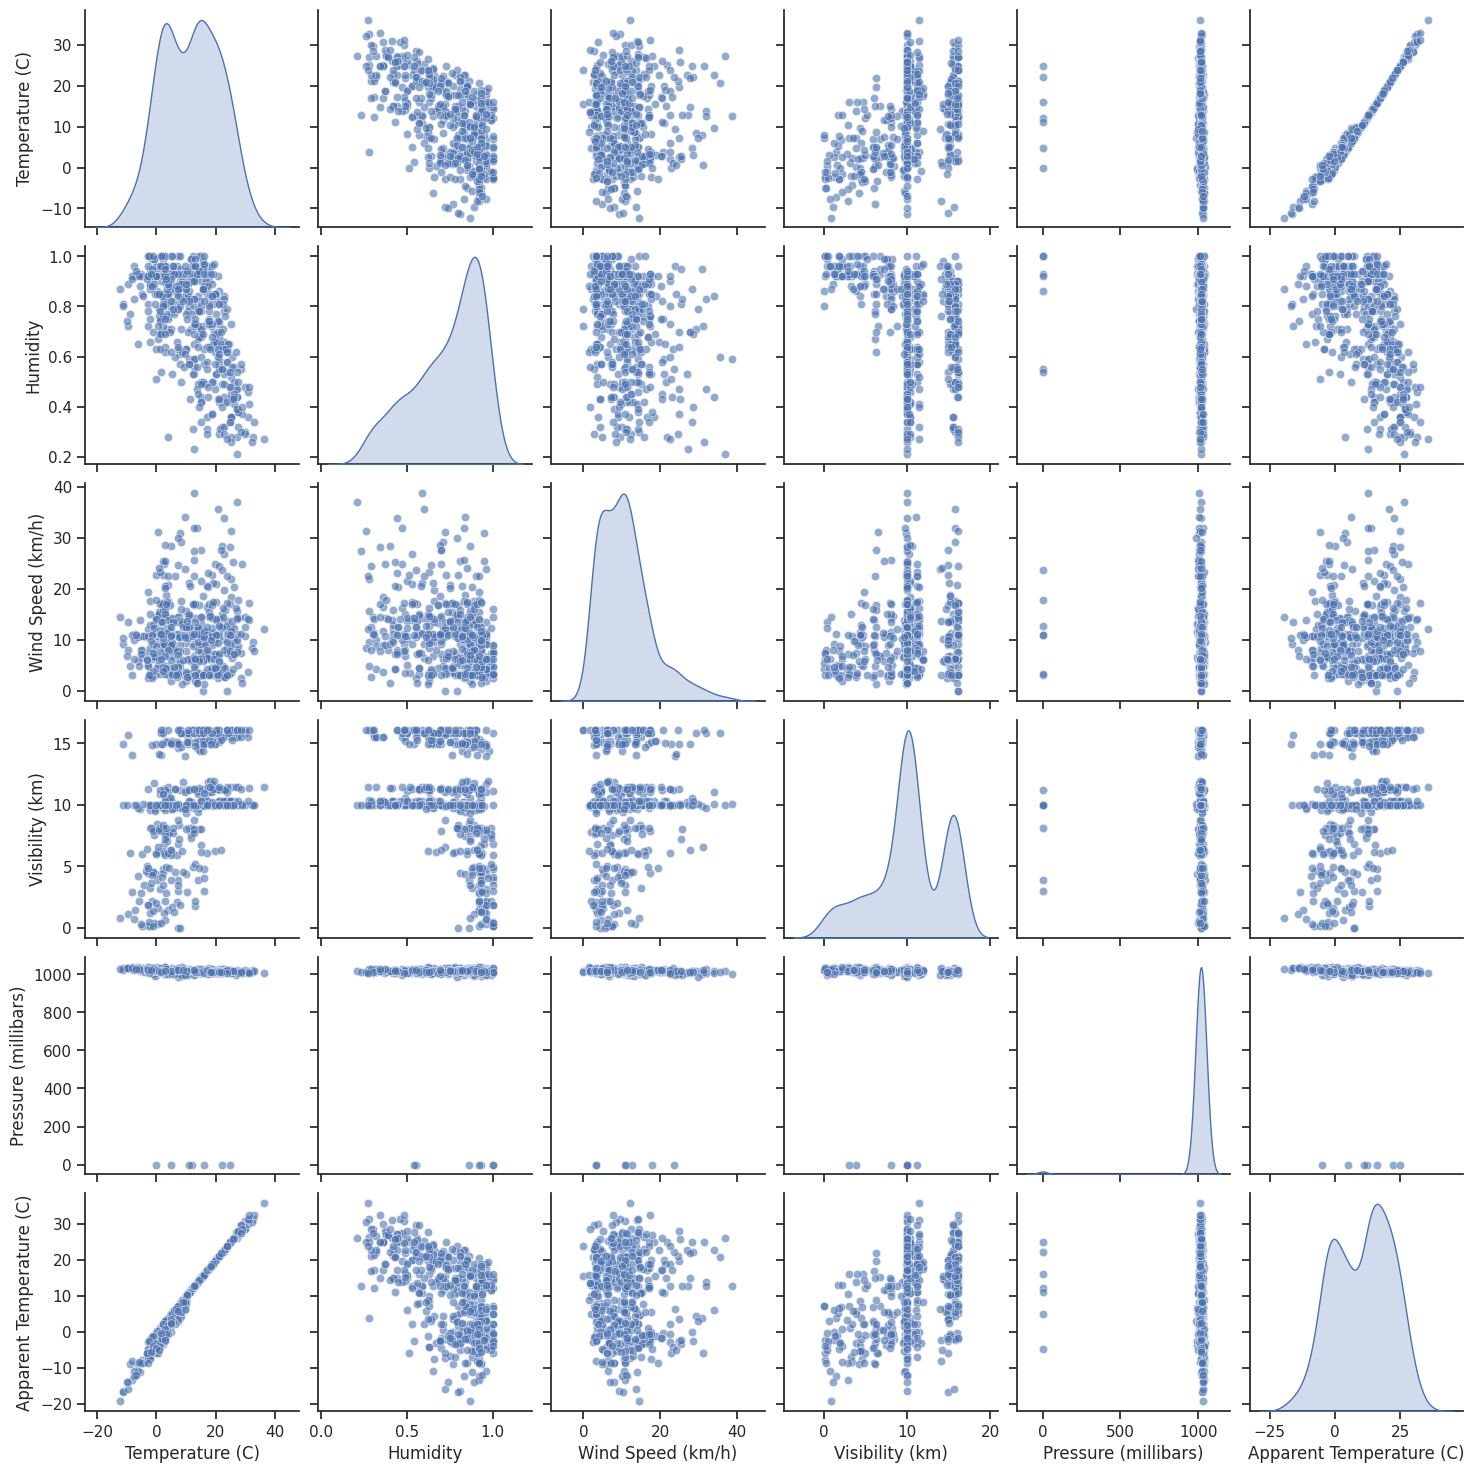

In [5]:
sns.set_theme(style="ticks")
pair_plot = sns.pairplot(df_sample, diag_kind="kde", plot_kws={'alpha': 0.6})
plt.show()

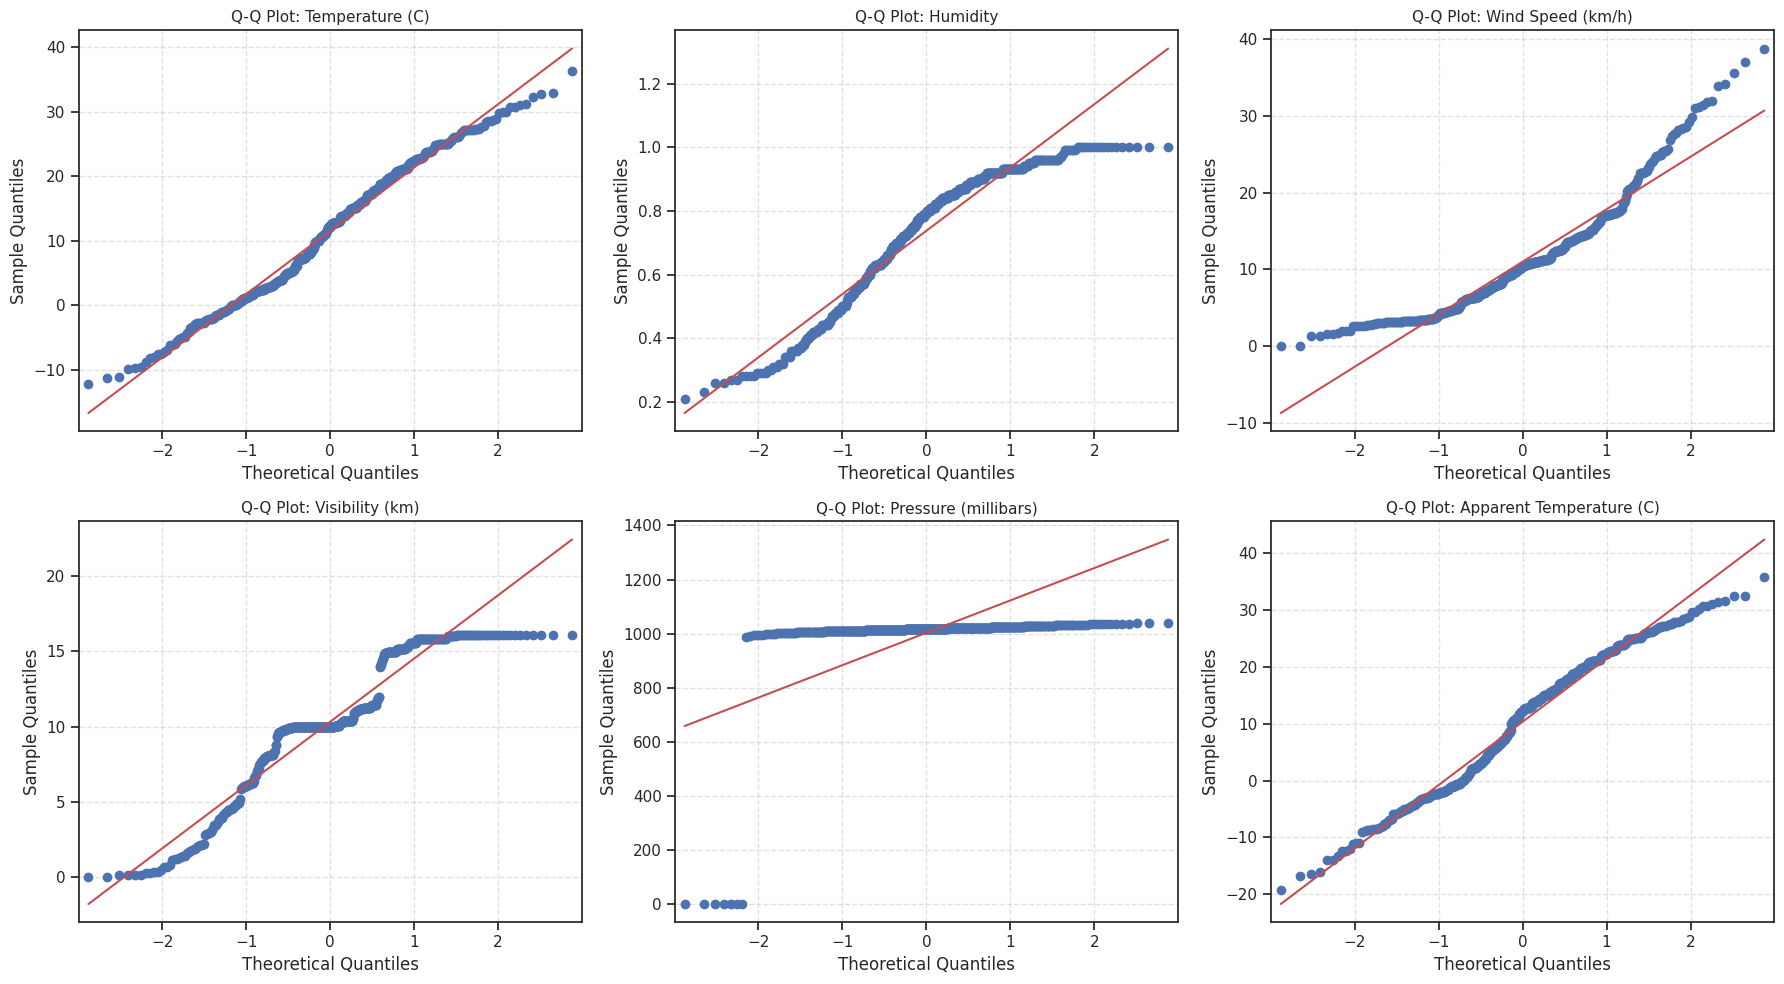


============================== SHAPIRO-WILK TEST SUMMARY ==============================


,Variable,W Statistic,p-value,Conclusion
0,Temperature (C),0.9845,0.00004,Not Normal (❌)
1,Humidity,0.9211,0.00000,Not Normal (❌)
2,Wind Speed (km/h),0.9154,0.00000,Not Normal (❌)
3,Visibility (km),0.9154,0.00000,Not Normal (❌)
4,Pressure (millibars),0.1339,0.00000,Not Normal (❌)
5,Apparent Temperature (C),0.9762,0.00000,Not Normal (❌)


In [6]:
shapiro_results = []

# 3. Կազմակերպում ենք գրաֆիկների միջավայրը (2 տող, 3 սյունակ)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 4. Գործարկում ենք ցիկլը բոլոր սյուների վրայով
for i, col in enumerate(all_features ):
    # Հաշվում ենք Shapiro-Wilk թեստը
    stat, p_value = stats.shapiro(df_sample[col])

    # Որոշում ենք արդյունքը
    status = "Normal (🎯)" if p_value > 0.05 else "Not Normal (❌)"

    # Պահպանում ենք աղյուսակի տվյալները
    shapiro_results.append({
        'Variable': col,
        'W Statistic': round(stat, 4),
        'p-value': round(p_value, 5),
        'Conclusion': status
    })
    sm.qqplot(df_sample[col].astype(float), line='s', ax=axes[i])
    axes[i].set_title(f'Q-Q Plot: {col}', fontsize=11)
    axes[i].grid(True, linestyle='--', alpha=0.6)

# 3. Դասավորում ենք գրաֆիկները և ցուցադրում
plt.tight_layout()
plt.show()

# 4. Ցուցադրում ենք Shapiro-Wilk թեստի ամփոփիչ աղյուսակը
df_shapiro_summary = pd.DataFrame(shapiro_results)
print("\n" + "="*30 + " SHAPIRO-WILK TEST SUMMARY " + "="*30)
display(df_shapiro_summary)

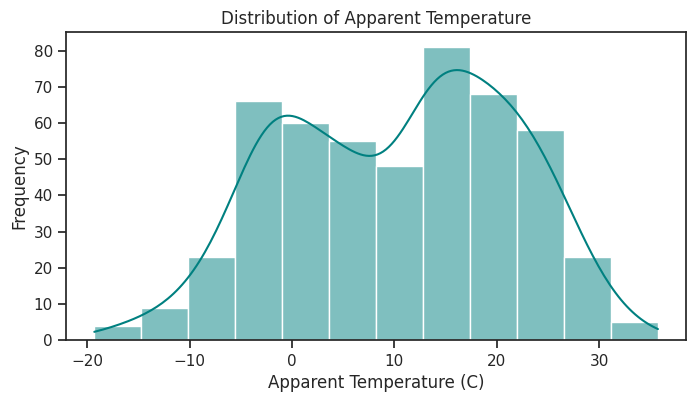

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(df_sample['Apparent Temperature (C)'], kde=True, color='teal')
plt.title('Distribution of Apparent Temperature')
plt.xlabel('Apparent Temperature (C)')
plt.ylabel('Frequency')
plt.show()

In [8]:
# 1. Առանձնացնում ենք բացատրող գործոնները (X) և թիրախը (y)
X_ols = df_sample[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)']]
y_ols = df_sample['Apparent Temperature (C)']

# 2. Ավելացնում ենք ազատ անդամը (Intercept-ը), որն անհրաժեշտ է statsmodels-ի համար
X_ols = sm.add_constant(X_ols)

# 3. Կառուցում և մարզում ենք Գծային ռեգրեսիայի մոդելը (Ordinary Least Squares)
ols_model = sm.OLS(y_ols, X_ols).fit()

# 4. Տպում ենք ամբողջական վիճակագրական ամփոփագիրը
print(ols_model.summary())

                               OLS Regression Results                               
Dep. Variable:     Apparent Temperature (C)   R-squared:                       0.991
Model:                                  OLS   Adj. R-squared:                  0.991
Method:                       Least Squares   F-statistic:                 1.098e+04
Date:                      Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                              14:05:32   Log-Likelihood:                -734.45
No. Observations:                       500   AIC:                             1481.
Df Residuals:                           494   BIC:                             1506.
Df Model:                                 5                                         
Covariance Type:                  nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

In [9]:
# 1. Առանձնացնում ենք գործոնները (X) և թիրախը (y)
X_pca_input = df_sample[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)']]
y_pca_input = df_sample['Apparent Temperature (C)']

# 2. Մասշտաբավորում ենք տվյալները (StandardScaler)
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_pca_input)

# 3. Կիրառում ենք PCA բոլոր 5 հնարավոր բաղադրիչների համար
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 4. Տպում ենք, թե ամեն մի բաղադրիչ (PC) տվյալների ընդհանուր ինֆորմացիայի որ տոկոսն է պահում
explained_variance = pca.explained_variance_ratio_
for i, var in enumerate(explained_variance):
    print(f"Principal component {i+1} (PC{i+1}): retains {var*100:.2f}% of the information")

Principal component 1 (PC1): retains 40.97% of the information
Principal component 2 (PC2): retains 20.30% of the information
Principal component 3 (PC3): retains 19.39% of the information
Principal component 4 (PC4): retains 12.97% of the information
Principal component 5 (PC5): retains 6.37% of the information


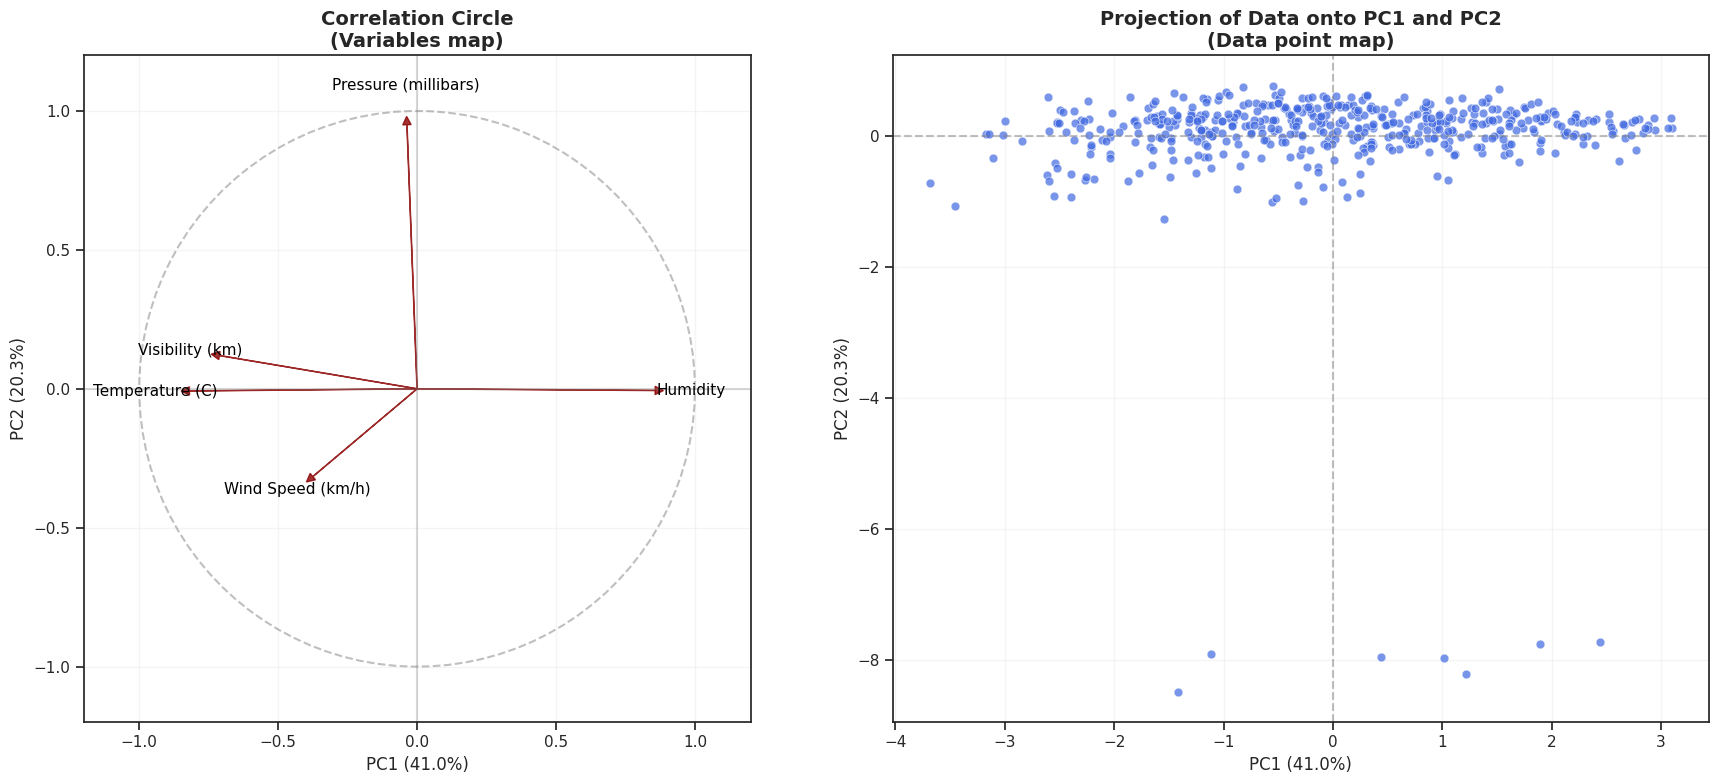

In [10]:
# Վերցնում ենք բացատրող փոփոխականների անունները ձեր X_pca_input-ից
# (Temperatrure, Humidity, և այլն)
feature_names = X_pca_input.columns.tolist()

# Բացատրվող վարիացիան առանցքների պիտակների համար (տոկոսներով)
var_exp = pca.explained_variance_ratio_

# Կազմակերպում ենք գրաֆիկների միջավայրը (1 տող, 2 սյունակ)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# ==========================================
# ԳՐԱՖԻԿ 1. Variables Map
# Այս գրաֆիկը ցույց է տալիս, թե ինչպես են ՕՐԻԳԻՆԱԼ ՓՈՓՈԽԱԿԱՆՆԵՐԸ
# կապված առաջին երկու հիմնական բաղադրիչների (PCs) հետ:
# ==========================================

# Շրջանի գծում
an = np.linspace(0, 2 * np.pi, 100)
ax1.plot(np.cos(an), np.sin(an), color="gray", linestyle="--", alpha=0.5)
ax1.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax1.axvline(0, color='gray', linestyle='-', alpha=0.3)

# Loadings հաշվարկ.
# Loads matrix = pca.components_ * sqrt(explained_variance_)
# In standard PCA on scaled data, these are the correlations
# between original variables and PCs.
# pca.components_ provides coefficients (directions),
# pca.explained_variance_ provides the eigenvalues (strengths).
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Պատկերում ենք վեկտորները (arrow) փոփոխականների համար
# (առաջին երկու PC-ների՝ PC1 և PC2 վրա)
for i, feature_name in enumerate(feature_names):
    ax1.arrow(0, 0, loadings[i, 0], loadings[i, 1],
              head_width=0.03, head_length=0.03, color='darkred', alpha=0.8)
    # Տեքստի դասավորում (շեղումով)
    ax1.text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15, feature_name,
             color='black', ha='center', va='center', fontsize=11)

# Առանցքների պիտակավորում տոկոսներով
ax1.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', fontsize=12)
ax1.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', fontsize=12)
ax1.set_xlim(-1.2, 1.2)
ax1.set_ylim(-1.2, 1.2)
ax1.set_aspect('equal') # շրջանային գրաֆիկի համար պարտադիր է
ax1.set_title('Correlation Circle\n(Variables map)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.2)


# ==========================================
# ԳՐԱՖԻԿ 2. ՏՎՅԱԼՆԵՐԻ ՊՐՈՅԵԿՑԻԱ (Individuals Map)
# Այս գրաֆիկը ցույց է տալիս, թե ինչպես են ՕՐԻԳԻՆԱԼ ՏՎՅԱԼՆԵՐԻ ԿԵՏԵՐԸ
# (df_sample-ի 500 տողերը) դասավորված PC1 և PC2 առանցքների վրա։
# ==========================================

# Օգտագործում ենք արդեն հաշվարկված X_pca (ձեր կոդից)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], alpha=0.7, color='royalblue', s=40, ax=ax2)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Առանցքների պիտակավորում (նույնը, ինչ շրջանի դեպքում)
ax2.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', fontsize=12)
ax2.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', fontsize=12)
ax2.set_title('Projection of Data onto PC1 and PC2\n(Data point map)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

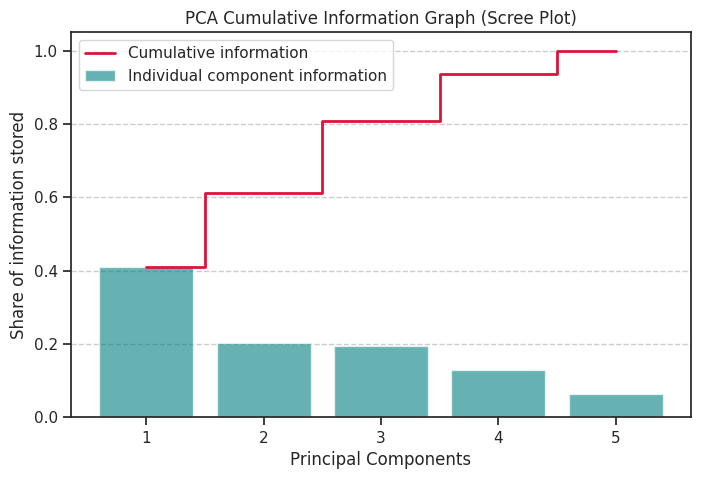

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), explained_variance, alpha=0.6, align='center', label='Individual component information', color='teal')
plt.step(range(1, 6), np.cumsum(explained_variance), where='mid', label='Cumulative information', color='crimson', linewidth=2)

plt.ylabel('Share of information stored')
plt.xlabel('Principal Components')
plt.title('PCA Cumulative Information Graph (Scree Plot)')
plt.xticks(range(1, 6))
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--')
plt.show()

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm

# Վերցնում ենք միայն անկախ գործոնները
X_vif = df_sample[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)']].astype(float)
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data.round(2))

                Feature     VIF
0                 const  139.40
1       Temperature (C)    1.85
2              Humidity    1.89
3     Wind Speed (km/h)    1.14
4       Visibility (km)    1.28
5  Pressure (millibars)    1.02


In [13]:
# 1. Առանձնացնում ենք X-ը (գործոններ) և y-ը (թիրախ) առանց constant-ի
X = df_sample[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)']]
y = df_sample['Apparent Temperature (C)']

# 2. Բաժանում ենք տվյալները Train և Test սեթերի (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)

# 3. Ստեղծում և կիրառում ենք Standard Scaler-ը
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:
# 1. Ստեղծում և մարզում ենք KNN մոդելը (օրինակ՝ 5 հարևանով)
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# 2. Անում ենք կանխատեսում թեստային տվյալների վրա
y_pred_knn = knn_model.predict(X_test_scaled)

# 3. Հաշվում ենք մոդելի արդյունավետությունը
knn_r2 = r2_score(y_test, y_pred_knn)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))

print(f"KNN Model R²: {knn_r2:.4f}")
print(f"KNN Model RMSE: {knn_rmse:.4f} °C")

KNN Model R²: 0.9555
KNN Model RMSE: 2.2678 °C


In [16]:
from sklearn.svm import SVR

# 1. Ստեղծում և մարզում ենք SVM մոդելը
svm_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svm_model.fit(X_train_scaled, y_train)

# 2. Անում ենք կանխատեսում
y_pred_svm = svm_model.predict(X_test_scaled)

# 3. Հաշվում ենք արդյունավետությունը
svm_r2 = r2_score(y_test, y_pred_svm)
svm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svm))

print(f"SVM Model R²: {svm_r2:.4f}")
print(f"SVM Model RMSE : {svm_rmse:.4f} °C")

SVM Model R²: 0.9531
SVM Model RMSE : 2.3286 °C
